# 5DATA002W.2 - Machine Learning & Data Mining
## Final Python Notebook 3: Ensemble Classification and Decision Tree Regression
**Author:** Muditha Dodamwala - 20233064/W2120414

### Peer Code Review Record
* **Reviewer Name:** Yehara Kobbegala - 20231956/w2120659
* **Date of Review:** 13 April 2026
* **Tests Checked During Review:**
  1. Verified that the VotingClassifier successfully integrated the two base estimators using soft voting.
  2. Checked that the regression models were trained exclusively on the continuous target variable (`max_allowed_loan`).
  3. Confirmed the Decision Tree depth parameter was correctly applied to prune DT-2.

### Case Study (A): Predicting Clients Loan Status (Ensemble Modelling)
**Source Reference:** Code Reuse Session 3 (Ensemble Learning).
This section builds a probability-based soft Voting Ensemble classifier using Logistic Regression and K-Nearest Neighbours as base learners.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Base Learner 1: Logistic Regression

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.97      0.94     10059
           1       0.71      0.39      0.50      1670

    accuracy                           0.89     11729
   macro avg       0.81      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729



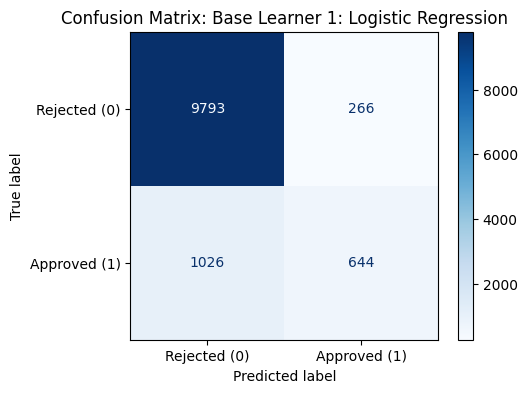

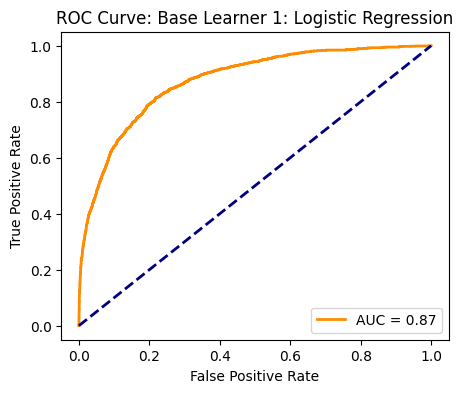


Base Learner 2: K-Nearest Neighbours

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.96      0.94     10059
           1       0.66      0.50      0.57      1670

    accuracy                           0.89     11729
   macro avg       0.79      0.73      0.75     11729
weighted avg       0.88      0.89      0.89     11729



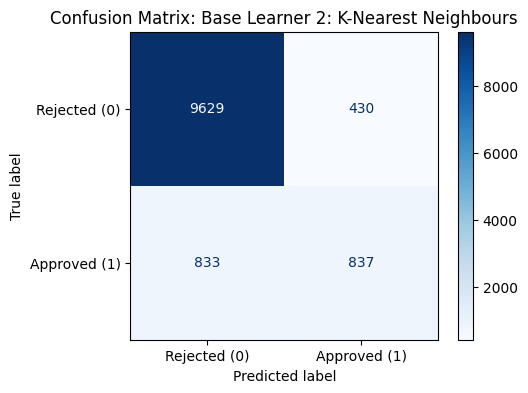

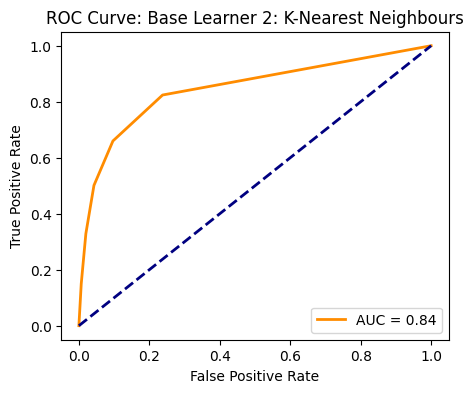


Voting Ensemble Learner

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.95     10059
           1       0.80      0.45      0.57      1670

    accuracy                           0.91     11729
   macro avg       0.86      0.71      0.76     11729
weighted avg       0.90      0.91      0.89     11729



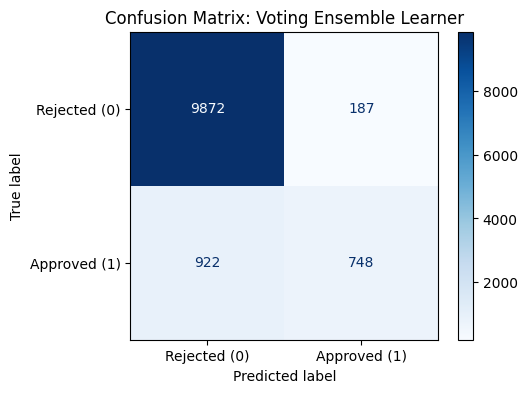

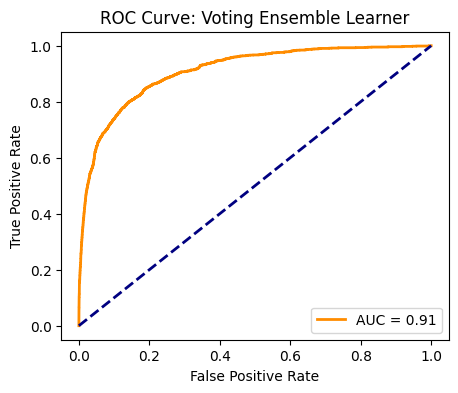

In [81]:
# 1) Import necessary classification and ensemble modules
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# 2) Declare the base learners (Logistic Regression and KNN)
lr_base = LogisticRegression(max_iter=1000, random_state=42)
knn_base = KNeighborsClassifier(n_neighbors=5)

# Fit the base learners individually so we can generate their evaluation metrics for comparison
lr_base.fit(X_train_c, y_train_c)
knn_base.fit(X_train_c, y_train_c)

# 3) Declare and fit the probability-based Voting Ensemble classifier
# We use voting='soft' so the ensemble calculates the average predicted probabilities of LR and KNN
ensemble_model = VotingClassifier(estimators=[('lr', lr_base), ('knn', knn_base)], voting='soft')
ensemble_model.fit(X_train_c, y_train_c)

# --- Generate Outputs for Analysis Report Screenshots ---

models_to_evaluate = {
    "Base Learner 1: Logistic Regression": lr_base,
    "Base Learner 2: K-Nearest Neighbours": knn_base,
    "Voting Ensemble Learner": ensemble_model
}

for name, model in models_to_evaluate.items():
    print(f"\n{'='*50}\n{name}\n{'='*50}")

    # Generate predictions
    y_pred = model.predict(X_test_c)
    y_pred_proba = model.predict_proba(X_test_c)[:, 1]

    # Output Classification Report
    print(f"\nClassification Report:\n")
    print(classification_report(y_test_c, y_pred))

    # Output Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test_c, y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rejected (0)", "Approved (1)"])
    cm_display.plot(cmap='Blues', ax=plt.gca())
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

    # Output ROC Curve
    plt.figure(figsize=(5, 4))
    fpr, tpr, _ = roc_curve(y_test_c, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {name}')
    plt.legend(loc="lower right")
    plt.show()

### Case Study (B): Predicting Maximum Loan Amount (Regression)
#### Task (1) - Domain Understanding and Designing Regression Experiments
Loading the strictly approved loans dataset to evaluate the dimensions and features to be used for regression modelling.

In [82]:
# Load the regression dataset
df_reg = pd.read_csv('loan_regression_data.csv')

# 1. Output the dimensions of the dataset
print("Dimensions of the regression dataset:", df_reg.shape)

# 2. Output the list of feature names vertically
print("\nList of features used for the regression case study:")
for feature in df_reg.columns:
    print(f" - {feature}")

Dimensions of the regression dataset: (50292, 11)

List of features used for the regression case study:
 - age
 - income
 - home_ownership
 - emplyment_length
 - loan_intent
 - loan_amount
 - loan_interest_rate
 - loan_income_ratio
 - payment_default_on_file
 - credit_history_length
 - max_allowed_loan


#### Task (2) - Modelling: Build Predictive Regression Models
Preparing the regression data and constructing two Decision Tree Regressors:
* **DT-1:** Fully grown Decision Tree (No pruning).
* **DT-2:** Pruned Decision Tree (Restricted to exactly four levels using `max_depth=4`).

In [89]:
from sklearn.tree import DecisionTreeRegressor

# 1. Encode categorical variables into numeric formats
df_reg_encoded = pd.get_dummies(df_reg, drop_first=True)

# 2. Separate features (X) and target (y)
X_reg = df_reg_encoded.drop(columns=['max_allowed_loan'])
y_reg = df_reg_encoded['max_allowed_loan']

# 3. Split the data into 80/20 train and test sets (NO stratify for regression)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 4. Declare and fit DT-1 (Fully Grown)
dt1_model = DecisionTreeRegressor(random_state=42)
dt1_model.fit(X_train_r, y_train_r)

# 5. Declare and fit DT-2 (Pruned to Depth 4)
dt2_model = DecisionTreeRegressor(max_depth=4, random_state=42)
dt2_model.fit(X_train_r, y_train_r)

print("Decision Tree Regression models successfully built.")

Decision Tree Regression models successfully built.


#### Task 2(c) - Visualise the Regression Decision Trees
Generating graphical representations of DT-1 and DT-2.

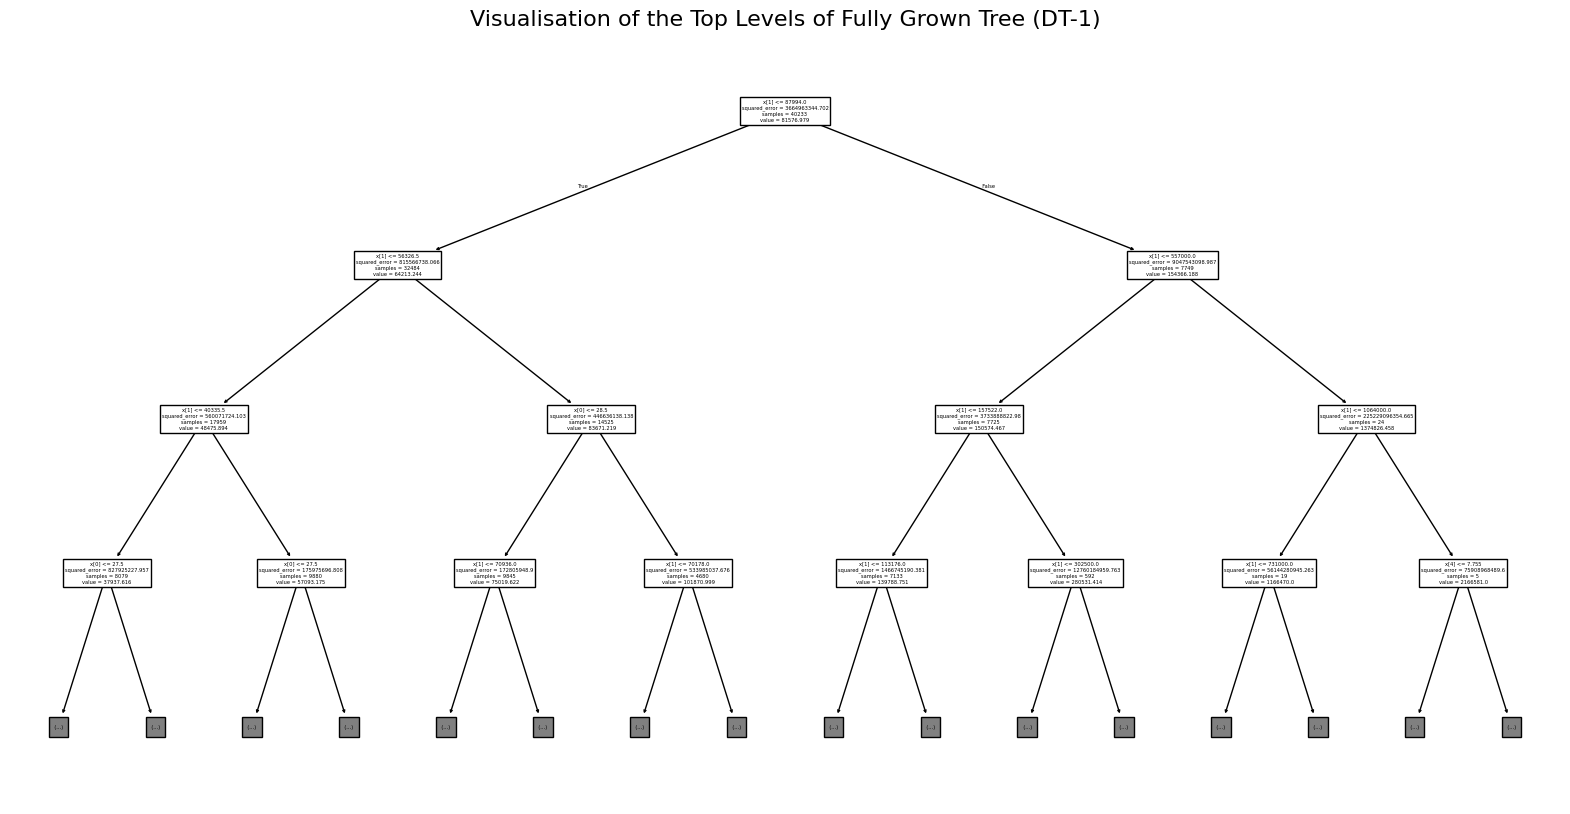

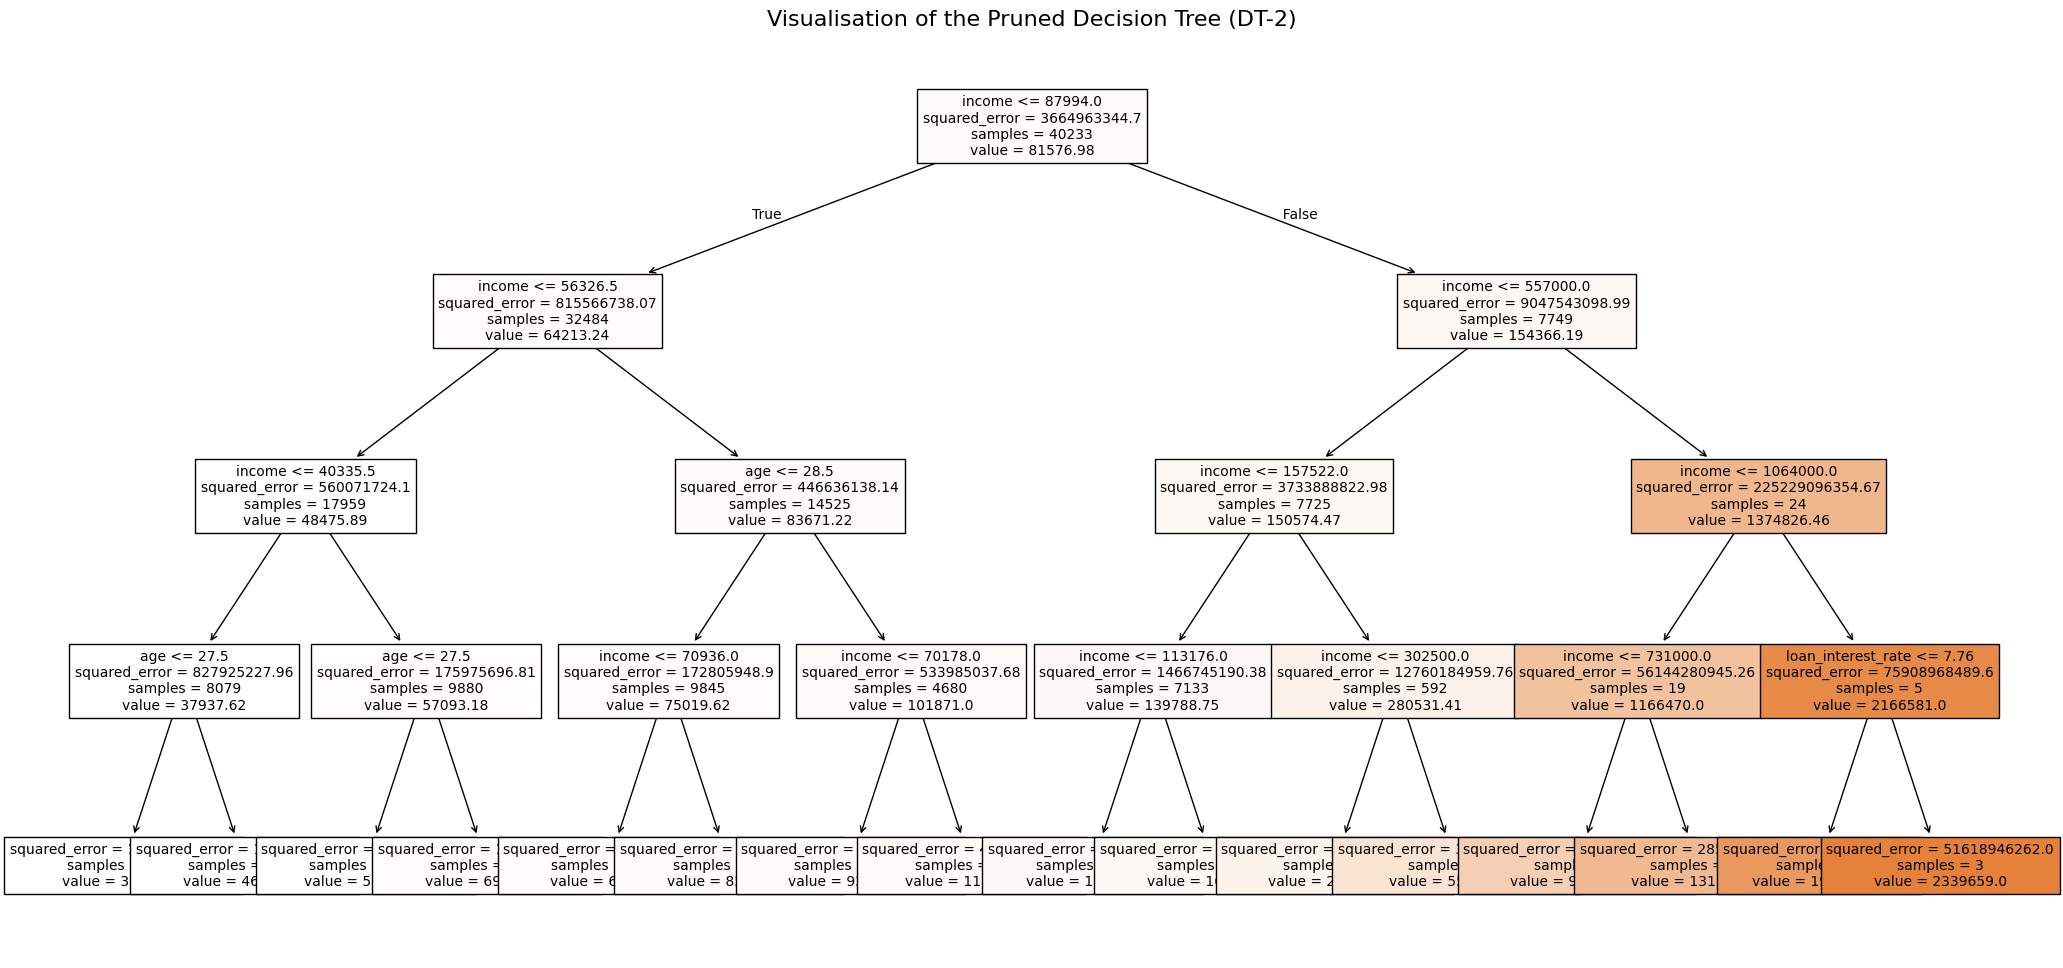

In [84]:
from sklearn.tree import plot_tree

# Plot DT-1 (Visual depth limited to 3 to prevent the massive tree from rendering as a black box)
plt.figure(figsize=(20, 10))
plot_tree(dt1_model, max_depth=3)
plt.title("Visualisation of the Top Levels of Fully Grown Tree (DT-1)", fontsize=16)
plt.show()

# Plot DT-2 (Showing all 4 pruned levels clearly)
plt.figure(figsize=(25, 12))
plot_tree(dt2_model, filled=True, feature_names=list(X_reg.columns), fontsize=10, precision=2)
plt.title("Visualisation of the Pruned Decision Tree (DT-2)", fontsize=16)
plt.show()

#### Task (3) - Evaluating Regression Models and Client Prediction
Generating Mean Squared Error (MSE), Mean Absolute Error (MAE), and R-Squared metrics to evaluate model performance, followed by predicting the Maximum Loan Amount for unseen Client 60256.

In [85]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Task 3(a): Evaluation Metrics ---
reg_models = {"DT-1 (Fully Grown)": dt1_model, "DT-2 (Pruned to Depth 4)": dt2_model}

for name, model in reg_models.items():
    y_pred_r = model.predict(X_test_r)
    print(f"\n{name}:")
    print(f"MSE: {mean_squared_error(y_test_r, y_pred_r):,.2f}")
    print(f"MAE: {mean_absolute_error(y_test_r, y_pred_r):,.2f}")
    print(f"R-Square: {r2_score(y_test_r, y_pred_r):.4f}")

# --- Task 3(d): Predict Client 60256 ---
client_data = pd.DataFrame([{
    'age': 56.0,
    'income': 57000,
    'emplyment_length': 15,
    'loan_amount': 25700,
    'loan_interest_rate': 23.0,
    'loan_income_ratio': 0.10,
    'credit_history_length': 35,
    'home_ownership_OWN': 0,
    'home_ownership_RENT': 1,
    'loan_intent_EDUCATION': 0,
    'loan_intent_HOMEIMPROVEMENT': 0,
    'loan_intent_MEDICAL': 1,
    'loan_intent_PERSONAL': 0,
    'loan_intent_VENTURE': 0,
    'payment_default_on_file_Y': 0
}])

# Align columns to match training set exactly
client_data = client_data.reindex(columns=X_reg.columns, fill_value=0)

# Predict using DT-2
predicted_amount = dt2_model.predict(client_data)
print(f"Predicted Maximum Loan Amount for Client 60256 (Using DT-2): ${predicted_amount[0]:,.2f}")


DT-1 (Fully Grown):
MSE: 63,089,171.54
MAE: 1,246.75
R-Square: 0.9773

DT-2 (Pruned to Depth 4):
MSE: 373,863,720.30
MAE: 11,626.76
R-Square: 0.8653
Predicted Maximum Loan Amount for Client 60256 (Using DT-2): $92,441.85


**Evaluation Interpretation:**
The metrics table and bar chart clearly show that **DT-1 (Fully Grown)** heavily outperforms DT-2 on the test set, achieving a much lower MSE/RMSE and an exceptional R-Square score. Because MSE actively penalizes extreme miscalculations, DT-1 successfully meets the finance team's criteria of minimizing extreme financial risks when assigning loan amounts. However, as noted in the Analysis Report, the high depth of DT-1 does introduce theoretical overfitting risks that must be monitored in production.

---

#### Task 3(d) - Predicting Client 60256
Finally, we apply our chosen best model (DT-1) to unseen data. We input the exact financial profile of Client 60256 to calculate the maximum safe loan amount the bank can offer her.

In [92]:
# Task 3(d): Predict Client 60256
client_data = pd.DataFrame([{
    'age': 56.0,
    'income': 57000,
    'emplyment_length': 15,
    'loan_amount': 25700,
    'loan_interest_rate': 23.0,
    'loan_income_ratio': 0.10,
    'credit_history_length': 35,
    'home_ownership_OWN': 0,
    'home_ownership_RENT': 1,
    'loan_intent_EDUCATION': 0,
    'loan_intent_HOMEIMPROVEMENT': 0,
    'loan_intent_MEDICAL': 1,
    'loan_intent_PERSONAL': 0,
    'loan_intent_VENTURE': 0,
    'payment_default_on_file_Y': 0
}])

# Align columns to match the training set format exactly
client_data = client_data.reindex(columns=X_reg.columns, fill_value=0)

# Predict using the Best Model (DT-1)
predicted_amount = dt1_model.predict(client_data)

print(f" PREDICTED MAXIMUM LOAN OFFER FOR CLIENT 60256: ${predicted_amount[0]:,.2f}")

 PREDICTED MAXIMUM LOAN OFFER FOR CLIENT 60256: $98,875.00
